# **Project: Nghiên cứu mô hình học đa phương thức dựa trên đồ thị, chuẩn đoán bệnh nghề nghiệp dựa trên ảnh X-quang và dữ liệu lâm sàng**
## **Nhánh Timeseries: Xử lý dữ liệu lâm sàng & Train Base Model (Đã tối ưu & chống rò rỉ dữ liệu)**

# Table of Contents
* [1. Load Data Linh Hoạt (Local / Google Sheet)](#loading-data)
* [2. Fill Missing & Outliers](#fill-missing)
* [3. Feature Engineering & Encoding](#encoding)
* [4. Phân Loại Nghề 10 Cấp Độ](#job-classification)
* [5. Tách Nhánh Dữ Liệu & Split Train/Val/Test](#data-splitting)
* [6. Kiến Trúc Mô Hình Keras Multi-Input](#model-architecture)
* [7. Huấn Luyện & Đánh Giá trên Tập Test Hold-out](#model-training)
* [8. Trích Xuất Vector Đặc Trưng Lâm Sàng cho Fusion](#feature-extraction)

In [3]:
# === Optional: Mount Google Drive if running on Google Colab ===
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✅ Mounted Google Drive successfully.")
except ImportError:
    print("ℹ️ Running in Local environment (Google Colab module not found). Skipping drive mount.")
except Exception as e:
    print(f"ℹ️ Could not mount Google Drive: {e}. Proceeding with local configuration.")

ℹ️ Running in Local environment (Google Colab module not found). Skipping drive mount.


In [4]:
# === 1) Load Data Linh Hoạt (Ưu tiên File Local -> Fallback Google Sheet) & Lọc Cột ===

import os
import re
from io import BytesIO
import pandas as pd
import requests

LOCAL_DATA_PATH = "data/Main_data_fixed_Not_Encode_Mapping_New.xlsx"
RAW_SHEET_URL = "https://docs.google.com/spreadsheets/d/1MBTFK4dw-PBbh8NA2HEaNo0_CVemTJfF/edit?usp=drive_link&ouid=103230800443557501737&rtpof=true&sd=true"

df_raw = None

# 1) Kiểm tra nạp từ Local File trước
if os.path.exists(LOCAL_DATA_PATH):
    print(f"✅ Tìm thấy dữ liệu Local: {LOCAL_DATA_PATH}. Đang nạp dữ liệu...")
    df_raw = pd.read_excel(LOCAL_DATA_PATH)
    print(f"✅ Loaded local data successfully. Shape: {df_raw.shape}")
else:
    print(f"⚠️ Không tìm thấy file local tại '{LOCAL_DATA_PATH}'. Đang tải từ Google Sheet URL...")
    m = re.search(r"/spreadsheets/d/([^/]+)/", RAW_SHEET_URL)
    if not m:
        raise ValueError("Không trích xuất được spreadsheet id từ RAW_SHEET_URL.")
    
    raw_sid = m.group(1)
    raw_export_url = f"https://docs.google.com/spreadsheets/d/{raw_sid}/export?format=xlsx"
    
    resp = requests.get(raw_export_url)
    if resp.status_code != 200 or (resp.headers.get("content-type", "").find("spreadsheet") == -1 and resp.content[:4] != b"PK\x03\x04"):
        raise RuntimeError(f"Không tải được .xlsx từ Google Sheet. status_code={resp.status_code}")
    
    df_raw = pd.read_excel(BytesIO(resp.content))
    print(f"✅ Loaded online raw data successfully. Shape: {df_raw.shape}")

# --- Lọc cột định danh & Cột rò rỉ X-quang ---
explicit_drop = {
    "id", "tinh", "hoten", "sdt", "sobh", "bnncuthe", "nam",
    # Cột kết quả/phân tích phim X-quang (tránh rò rỉ sang nhánh ảnh)
    "chatluongphim", "ketqua", "matdotonthuong", "tonthuongkhac", "kichthuoctt",
}

pattern_drop = []
for col in df_raw.columns:
    c = str(col).strip()
    if re.match(r"^[BCDE]\s*\d+", c, flags=re.IGNORECASE):
        pattern_drop.append(col)
        continue
    m_f = re.match(r"^F\s*(\d+)", c, flags=re.IGNORECASE)
    if m_f:
        f_num = int(m_f.group(1))
        if 1 <= f_num <= 3 or 6 <= f_num <= 13:
            pattern_drop.append(col)
            continue

cols_to_drop = []
for c in df_raw.columns:
    if str(c).strip().lower() in explicit_drop:
        cols_to_drop.append(c)
cols_to_drop.extend(pattern_drop)

seen = set()
cols_to_drop = [c for c in cols_to_drop if not (c in seen or seen.add(c))]

before_cols = df_raw.shape[1]
df_pruned = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns], errors="ignore")
after_cols = df_pruned.shape[1]

print("\n✅ Pruned columns (loại bỏ thông tin cá nhân & dữ liệu X-quang):")
print(f"- Số cột trước khi lọc: {before_cols}")
print(f"- Số cột đã loại bỏ:   {len(cols_to_drop)}")
print(f"- Số cột còn lại:       {after_cols}")

✅ Tìm thấy dữ liệu Local: data/Main_data_fixed_Not_Encode_Mapping_New.xlsx. Đang nạp dữ liệu...
✅ Loaded local data successfully. Shape: (8030, 181)

✅ Pruned columns (loại bỏ thông tin cá nhân & dữ liệu X-quang):
- Số cột trước khi lọc: 181
- Số cột đã loại bỏ:   57
- Số cột còn lại:       124


In [5]:
# === 2) Bổ sung data thiếu & Xử lý bất thường đặc thù ===

missing_counts = df_pruned.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

rows = []
for col, cnt in missing_counts.items():
    s = df_pruned[col]
    if pd.api.types.is_numeric_dtype(s):
        kind = "numeric"
        convertible_ratio = 1.0
    else:
        s_non_missing = s.dropna()
        if len(s_non_missing) == 0:
            kind = "text"
            convertible_ratio = 0.0
        else:
            coerced = pd.to_numeric(s_non_missing, errors="coerce")
            convertible_ratio = float(coerced.notna().mean())
            kind = "numeric" if convertible_ratio >= 0.95 else "text"

    rows.append({
        "column": str(col),
        "dtype": str(s.dtype),
        "kind": kind,
        "convertible_ratio": round(convertible_ratio, 4),
        "missing_count": int(cnt),
        "fill_value": 0 if kind == "numeric" else "không",
    })

filled_df = df_pruned.copy()
num_cols = [r["column"] for r in rows if r["kind"] == "numeric"]
text_cols = [r["column"] for r in rows if r["kind"] == "text"]

for c in num_cols:
    filled_df[c] = pd.to_numeric(filled_df[c], errors="coerce").fillna(0)

if text_cols:
    filled_df[text_cols] = filled_df[text_cols].fillna("không")

# 3.1) Sửa giá trị bất thường ở F4gang ('6.0' -> mode)
if "F4gang" in filled_df.columns:
    filled_df["F4gang"] = filled_df["F4gang"].astype(str).str.strip()
    outlier_mask = filled_df["F4gang"].isin(["6.0", "6"])
    n_outliers = outlier_mask.sum()
    if n_outliers > 0:
        valid_data = filled_df.loc[~outlier_mask, "F4gang"]
        if not valid_data.empty:
            true_mode = valid_data.mode().iloc[0]
            filled_df.loc[outlier_mask, "F4gang"] = true_mode
            print(f"✅ Đã thay {n_outliers} giá trị '6.0' ở F4gang bằng mode = '{true_mode}'.")

# 3.2) Tách riêng cột file_name thành mảng để ánh xạ sang nhánh ảnh X-quang
if "file_name" in filled_df.columns:
    file_names = filled_df["file_name"].astype(str).values
    print("✅ Đã tách cột file_name ra mảng  (len =", len(file_names), ")")
    filled_df = filled_df.drop(columns=["file_name"])
else:
    file_names = None

print(f"✅ Filled missing data complete. Remaining missing cells: {filled_df.isna().sum().sum()}")

✅ Đã thay 1 giá trị '6.0' ở F4gang bằng mode = 'Rat thuong xuyen'.
✅ Đã tách cột file_name ra mảng  (len = 8030 )
✅ Filled missing data complete. Remaining missing cells: 0


In [6]:
# === 3) Feature Engineering & Encoding (Binary, Ordinal, One-Hot, Age Calculation) ===

import pandas as pd
import numpy as np

df = filled_df.copy()

def _to_lower_str(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip().str.lower()

def _binary_khong_or_nan_to_0_else_1(s: pd.Series) -> pd.Series:
    ss = _to_lower_str(s)
    return (~(ss.isna() | (ss == "khong"))).astype(int)

def _safe_cols(cols):
    return [c for c in cols if c in df.columns]

# --- 1) Binary Encoding (0/1) ---
if "gioitinh" in df.columns:
    g = _to_lower_str(df["gioitinh"])
    df["gioitinh"] = g.map({"nam": 0, "nu": 1}).fillna(0).astype(int)

if "longnguc" in df.columns:
    ln = _to_lower_str(df["longnguc"])
    df["longnguc"] = ln.map({"can doi": 0, "khong can doi": 1}).fillna(0).astype(int)

for c in _safe_cols(["khoangls", "rungthan", "go", "riraopn"]):
    ss = _to_lower_str(df[c])
    df[c] = (ss != "binh thuong").fillna(False).astype(int)

binary_khong_cols = [
    "cv5nam", "hutthuoc", "tiensuhh", "benhhh", "tsnoi", "tsngoai", "ho", "n1",
    "khacdom", "khotho", "daunguc", "daulan", "tcdau", "n2", "n3", "ytotang",
    "chaymui", "khan", "khokhe", "dhkhac", "metmoi", "sutcan", "vitridau",
    "ytodau", "rungt1", "rungt2", "rungt3", "rungt4", "rungt5", "rungt6",
    "rungg1", "rungg2", "rungg3", "rungg4", "rungg5", "rungg6", "goduc1",
    "goduc2", "goduc3", "goduc4", "goduc5", "goduc6", "ran", "ranam", "ranno",
    "ranrit", "ranngay", "vtam1", "vtam2", "vtam3", "vtam4", "vtam5", "vtam6",
    "vtno1", "vtno2", "vtno3", "vtno4", "vtno5", "vtno6", "vtrit1", "vtrit2",
    "vtrit3", "vtrit4", "vtrit5", "vtrit6", "vtngay1", "vtngay2", "vtngay3",
    "vtngay4", "vtngay5", "vtngay6", "A12", "bnn",
]

for c in _safe_cols(binary_khong_cols):
    df[c] = _binary_khong_or_nan_to_0_else_1(df[c])

# --- 2) Ordinal Encoding ---
ordinal_maps = {
    "tdho": {"khong": 0, "ban ngay": 1, "ban dem": 2, "ca ngay va dem": 3},
    "tsho": {"khong": 0, "khac": 1, "tung con": 2, "lien tuc": 3},
    "loaidom": {"khong": 0, "0": 0, "dom nhay": 1, "dom mu": 2, "dom ba dau": 2, "dom mau": 3},
    "tdkhacdo": {"khong": 0, "ban ngay": 1, "ban dem": 2, "ca ngay va dem": 3},
    "mdkhotho": {"khong": 0, "khi gang suc": 1, "khi lam viec nhe": 2, "tung con": 3, "thuong xuyen": 4},
    "tdkhotho": {"khong": 0, "ban ngay": 1, "ban dem": 2, "ca ngay va dem": 3},
}

for col, mp in ordinal_maps.items():
    if col in df.columns:
        ss = _to_lower_str(df[col])
        df[col] = ss.map(mp).fillna(0).astype(int)

f4_map = {
    "khong su dung": 4, "hiem khi": 3, "thinh thoang": 2,
    "thuong xuyen": 1, "rat thuong xuyen": 0,
}
f4_cols = [c for c in df.columns if str(c).startswith("F4")]
for c in f4_cols:
    ss = _to_lower_str(df[c])
    df[c] = ss.map(f4_map).fillna(0).astype(int)

# --- 3) One-Hot Encoding ---
ohe_cols = _safe_cols(["A6", "A7", "A10", "A11"])
if ohe_cols:
    dummies = pd.get_dummies(df[ohe_cols], prefix=ohe_cols, drop_first=False).astype(int)
    df = pd.concat([df.drop(columns=ohe_cols), dummies], axis=1)

# --- 4) Tính Tuổi từ namsinh & Ép kiểu Numeric ---
if "namsinh" in df.columns:
    namsinh_num = pd.to_numeric(df["namsinh"], errors="coerce").fillna(1970)
    df["tuoi"] = (2026 - namsinh_num).clip(lower=15, upper=100)
    df = df.drop(columns=["namsinh"])

num_cols_all = [
    "tuoi", "tuoinghe", "nampx", "tgian1", "tgian2", "cao", "can", "hatd", "hatt",
    "mach", "theluc", "slthuoc", "tgdau", "socansut", "tgsut", "A9a", "A9b",
    "fvclt", "fvctt", "fev1lt", "fev1tt", "fvc", "fev1", "gaenler",
]
num_cols = _safe_cols(num_cols_all)

for c in num_cols:
    if df[c].dtype == object or str(df[c].dtype).startswith("string"):
        df[c] = df[c].astype("string").str.replace(",", ".", regex=False).str.strip()
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("✅ Encoding completed successfully. (Scaling will be done AFTER train/val/test split to avoid data leakage).")
print(f"Data shape: {df.shape}")

✅ Encoding completed successfully. (Scaling will be done AFTER train/val/test split to avoid data leakage).
Data shape: (8030, 140)


In [7]:
# === 4) Text Normalization + Phân nhóm 10 cấp độ -> ID số nguyên (0-9) trên df ===

import re
import unicodedata
import pandas as pd

try:
    from unidecode import unidecode as _unidecode
except ImportError:
    _unidecode = None

JOB_COLS = ["cviec", "pxuong", "cviec1", "cviec2"]
LV9_ID = 8  # lv9: Không đi làm / không xác định

level_to_id = {f"lv{i}": i - 1 for i in range(1, 10)}
level_to_id["lv10"] = 9

def _remove_vietnamese_accents(text: str) -> str:
    if _unidecode is not None:
        return _unidecode(text)
    normalized = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in normalized if not unicodedata.combining(ch))

def clean_job_text(text) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    s = str(text).strip().lower()
    if s in {"", "nan", "none", "<na>"}:
        return ""
    s = re.sub(r"\s+", " ", s)
    s = s.replace("đ", "d").replace("Đ", "d")
    s = _remove_vietnamese_accents(s)
    s = re.sub(r"\bsau chua\b", "sua chua", s)
    s = s.replace("x-ray", "x ray").replace("x ray", "x ray")
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _has_phrase(text: str, phrase: str) -> bool:
    if not phrase:
        return False
    if " " in phrase:
        return phrase in text
    return re.search(rf"\b{re.escape(phrase)}\b", text) is not None

def _match_keywords(text: str, keywords, short_boundary=None) -> bool:
    short_boundary = short_boundary or set()
    for kw in sorted(keywords, key=len, reverse=True):
        if kw in short_boundary:
            if re.search(rf"\b{re.escape(kw)}\b", text):
                return True
        elif _has_phrase(text, kw):
            return True
    return False

def classify_job_10_levels(clean_text: str) -> str:
    t = clean_text or ""
    if t == "" or t in {"khong", "nan", "o nha", "tu do"}:
        return "lv9"
    lv1_keywords = ["luyen", "duc", "nau", "nan", "no min", "ren", "dot", "chung cat", "khai thac", "cat", "nung", "coc", "thep", "gang", "silic", "da", "than", "lo", "mo", "kim loai", "xi mang", "clinker", "nghien", "amiang"]
    if _match_keywords(t, lv1_keywords): return "lv1"
    lv2_keywords = ["gia cong", "xay", "boc", "boc vac", "khoan", "mai", "pha", "trang men", "trang tri", "tron", "cong truong", "phu ho", "xay dung", "dap", "gach", "gach men", "ceramic", "tho"]
    if _match_keywords(t, lv2_keywords): return "lv2"
    lv3_keywords = ["phoi lieu", "tao hinh", "sua", "sua chua", "bao tri", "bao duong", "dien", "han", "ren", "co khi", "phay"]
    if _match_keywords(t, lv3_keywords): return "lv3"
    lv4_keywords = ["can", "dong", "det", "phan loai", "xuat vo", "soi"]
    if _match_keywords(t, lv4_keywords): return "lv4"
    if "bao ve" not in t and _has_phrase(t, "bao"): return "lv4"
    lv5_short = {"cn", "lam", "px", "vs", "con", "sx"}
    lv5_keywords = ["cong nhan", "lao dong", "san xuat", "xuat", "nguyen lieu", "nhap lieu", "nap lieu", "san pham", "say", "tron", "ve sinh", "xa", "truc", "bao ve", "cong ty", "cty", "kcn", "cong nghiep", "lien doanh", "nha may", "xi nghiep", "lap rap", "day chuyen", *lv5_short]
    if _match_keywords(t, lv5_keywords, short_boundary=lv5_short): return "lv5"
    lv6_short = {"vh", "dieu", "in", "ky"}
    lv6_keywords = ["chay", "dieu khien", "dung", "ky thuat", "lai", "may", "xe", "truc", "xu ly", "van chuyen", "van tai", *lv6_short]
    if _match_keywords(t, lv6_keywords, short_boundary=lv6_short): return "lv6"
    lv7_short = {"xn"}
    lv7_keywords = ["thi nghiem", "xet nghiem", "dem", "kiem", "ktra", "lay mau", "lab", "qc", "kcs", "x ray", *lv7_short]
    if _match_keywords(t, lv7_keywords, short_boundary=lv7_short): return "lv7"
    lv8_keywords = ["giam sat", "ke hoach", "kinh doanh", "kho vat tu", "quan ly", "ql", "qly", "giam doc", "nhan vien", "nv", "pho", "phong", "quan", "quat", "quy cach", "so lieu", "truong", "chi huy", "giay to", "thong", "cung cap", "ban", "buon ban", "chup anh", "chuyen vien", "di hoc", "bo doi", "quan su", "du lich", "ks", "nuoi", "nong nghiep", "gia suc", "gia cam", "noi", "quang cao", "sales", "shop", "giay", "quan ao", "thuc pham", "tiep thi", "bep", "nau an", "tap vu", "y te", "thiet ke", "ke toan"]
    if _match_keywords(t, lv8_keywords, short_boundary={"ql", "nv", "ks"}): return "lv8"
    return "lv10"

unique_values = pd.unique(pd.concat([df[c] for c in JOB_COLS], ignore_index=True))
raw_to_id_dict = {raw: level_to_id[classify_job_10_levels(clean_job_text(raw))] for raw in unique_values}
for col in JOB_COLS:
    df[col] = df[col].map(raw_to_id_dict).fillna(LV9_ID).astype(int)

print("✅ Đã chuyển 4 cột nghề nghiệp sang ID số nguyên (0-9) trên df")

✅ Đã chuyển 4 cột nghề nghiệp sang ID số nguyên (0-9) trên df


In [8]:
# === 5) Tách Nhánh Dữ Liệu & Split Train/Val/Test + Undersampling Tập Train (Chống Rò Rỉ) ===

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

JOB_COLS = ["cviec", "pxuong", "cviec1", "cviec2"]
TARGET_COL = "bnn"  # Target chuẩn: Bệnh nghề nghiệp
SEQ_PREFIXES = ["rungt", "rungg", "goduc", "vtam", "vtno", "vtrit", "vtngay"]
RANDOM_STATE = 42
USE_UNDERSAMPLING_TRAIN = True  # 🟢 BẬT UNDERSAMPLING TRÊN TẬP TRAIN (Tỷ lệ 1 Bệnh : 5 Khỏe)
UNDERSAMPLE_RATIO = 5  # 5 người khỏe trên 1 người bệnh

# --- 1) Chuỗi lâm sàng không gian (LSTM Input: 6 vùng phổi) ---
seq_features = []
seq_cols_flat = []
for i in range(1, 7):
    zone_cols = [f"{p}{i}" for p in SEQ_PREFIXES if f"{p}{i}" in df.columns]
    if not zone_cols:
        raise ValueError(f"Không tìm thấy cột chuỗi cho vùng i={i}")
    seq_cols_flat.extend(zone_cols)
    seq_features.append(df[zone_cols].values.astype(np.float32))

X_seq_all = np.stack(seq_features, axis=1)  # [N, 6, n_features_per_zone]

# --- 2) Cột số & Cột tĩnh ---
exclude_cols = set(seq_cols_flat) | set(JOB_COLS) | {TARGET_COL, "bnncuthe", "benhhh", "tiensuhh", "id", "hoten"}
num_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
X_num_all_raw = df[num_cols].to_numpy(dtype=np.float32)
X_job_all = df[JOB_COLS].to_numpy(dtype=np.int32)
y = df[TARGET_COL].astype(int).to_numpy()

print(f"✅ Class distribution for target '{TARGET_COL}':", dict(zip(*np.unique(y, return_counts=True))))

# --- 3) Chia tập dữ liệu chuẩn 3 phần: 70% Train - 15% Validation - 15% Test ---
idx = np.arange(len(df))
idx_train_val, idx_test = train_test_split(idx, test_size=0.15, random_state=RANDOM_STATE, stratify=y)
val_relative_ratio = 0.15 / 0.85
idx_train, idx_val = train_test_split(idx_train_val, test_size=val_relative_ratio, random_state=RANDOM_STATE, stratify=y[idx_train_val])

# --- 4) Fit Imputer & Scaler CHỈ TRÊN TRAIN SET (Chống Data Leakage) ---
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()

X_num_train_imp = imputer.fit_transform(X_num_all_raw[idx_train])
X_train_num = scaler.fit_transform(X_num_train_imp)
X_num_val_imp = imputer.transform(X_num_all_raw[idx_val])
X_val_num = scaler.transform(X_num_val_imp)
X_num_test_imp = imputer.transform(X_num_all_raw[idx_test])
X_test_num = scaler.transform(X_num_test_imp)
X_num_all = scaler.transform(imputer.transform(X_num_all_raw))

X_train_seq, X_val_seq, X_test_seq = X_seq_all[idx_train], X_seq_all[idx_val], X_seq_all[idx_test]
X_train_job, X_val_job, X_test_job = X_job_all[idx_train], X_job_all[idx_val], X_job_all[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

# --- 5) Undersampling CHỈ trên Tập TRAIN (Giữ nguyên tập Val & Test) ---
if USE_UNDERSAMPLING_TRAIN:
    np.random.seed(RANDOM_STATE)
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]
    n_pos = len(pos_idx)
    n_neg_target = min(len(neg_idx), n_pos * UNDERSAMPLE_RATIO)
    selected_neg_idx = np.random.choice(neg_idx, size=n_neg_target, replace=False)
    resampled_idx = np.concatenate([pos_idx, selected_neg_idx])
    np.random.shuffle(resampled_idx)
    
    X_train_job = X_train_job[resampled_idx]
    X_train_seq = X_train_seq[resampled_idx]
    X_train_num = X_train_num[resampled_idx]
    y_train = y_train[resampled_idx]
    print(f"⚡ Đã thực hiện Random Undersampling tập TRAIN theo tỷ lệ 1:{UNDERSAMPLE_RATIO}.")

# Tính class weight mới cân bằng trên y_train đã resample
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print("\n" + "=" * 60)
print("SHAPES — SPLIT DATA (Train Resampled / Val 15% / Test 15% Hold-out)")
print("=" * 60)
print(f"Train set: {len(y_train)} mẫu (Phân phối nhãn Train: {dict(zip(*np.unique(y_train, return_counts=True)))})")
print(f"Val set:   {len(y_val)} mẫu | Test set: {len(y_test)} mẫu")
print(f"Class weights: {class_weights_dict}")


✅ Class distribution for target 'bnn': {np.int64(0): np.int64(7819), np.int64(1): np.int64(211)}

SHAPES — SPLIT DATA (Train 70% / Val 15% / Test 15%)
Train set: 5620 mẫu | Val set: 1205 mẫu | Test set: 1205 mẫu
X_train_seq: (5620, 6, 7) | X_train_num: (5620, 91) | X_train_job: (5620, 4)
Class weights: {0: 0.5134295633107985, 1: 19.1156462585034}


In [9]:
# === 6) Multi-Input Keras Model (Cải tiến với BatchNormalization & Dropout) ===

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

n_seq_features = X_train_seq.shape[2]
n_num_features = X_train_num.shape[1]
n_job_slots = X_train_job.shape[1]

# --- Nhánh 1: Categorical Embedding (Nghề nghiệp) ---
job_input = layers.Input(shape=(n_job_slots,), name="job_input")
x_job = layers.Embedding(input_dim=10, output_dim=8, name="job_embedding")(job_input)
x_job = layers.GlobalAveragePooling1D(name="job_pool")(x_job)
x_job = layers.Dense(16, activation="relu", name="job_dense")(x_job)
x_job = layers.BatchNormalization(name="job_bn")(x_job)

# --- Nhánh 2: LSTM (Chuỗi lâm sàng 6 vùng) ---
seq_input = layers.Input(shape=(6, n_seq_features), name="seq_input")
x_seq = layers.LSTM(32, return_sequences=False, name="lstm_clinical")(seq_input)
x_seq = layers.BatchNormalization(name="lstm_bn")(x_seq)
x_seq = layers.Dense(16, activation="relu", name="seq_dense")(x_seq)

# --- Nhánh 3: Dense (Chỉ số lâm sàng số) ---
num_input = layers.Input(shape=(n_num_features,), name="num_input")
x_num = layers.Dense(32, activation="relu", name="num_dense1")(num_input)
x_num = layers.BatchNormalization(name="num_bn1")(x_num)
x_num = layers.Dropout(0.2)(x_num)
x_num = layers.Dense(16, activation="relu", name="num_dense2")(x_num)

# --- Fusion & Classification Head ---
merged = layers.Concatenate(name="fusion_concat")([x_job, x_seq, x_num])
x = layers.Dense(32, activation="relu", name="fusion_dense")(merged)
x = layers.BatchNormalization(name="fusion_bn")(x)
x = layers.Dropout(0.3, name="fusion_dropout")(x)
output = layers.Dense(1, activation="sigmoid", name="output")(x)

model = Model(
    inputs=[job_input, seq_input, num_input],
    outputs=output,
    name="multimodal_bnn_classifier",
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

model.summary()

I0000 00:00:1784258309.332259 1034999 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784258311.116768 1034999 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784258313.086621 1034999 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
Matplotlib is building the font cache; this may take a moment.
E0000 00:00:1784258323.089318 1034999 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "multimodal_bnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ job_input           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 91)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_embedding       │ (None, 4, 8)      │         80 │ job_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 6, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense1 (Dense)  │ (None, 32)        │      2,944 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_pool            │ (None, 8)         │          0 │ job_embedding[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_clinical       │ (None, 32)        │      5,120 │ seq_input[0][0]   │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_bn1             │ (None, 32)        │        128 │ num_dense1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_dense (Dense)   │ (None, 16)        │        144 │ job_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_bn             │ (None, 32)        │        128 │ lstm_clinical[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ num_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_bn              │ (None, 16)        │         64 │ job_dense[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_dense (Dense)   │ (None, 16)        │        528 │ lstm_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense2 (Dense)  │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 48)        │          0 │ job_bn[0][0],     │
│ (Concatenate)       │                   │            │ seq_dense[0][0],  │
│                     │                   │            │ num_dense2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 32)        │      1,568 │ fusion_concat[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 32)        │        128 │ fusion_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 32)        │          0 │ fusion_bn[0][0]   │
│ (Dropout)           │                   │            │                 

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,169 (43.63 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9320 - auc: 0.9793 - loss: 0.1855 - pr_auc: 0.5740 - val_accuracy: 0.9344 - val_auc: 0.9092 - val_loss: 0.2107 - val_pr_auc: 0.4317 - learning_rate: 3.1250e-05
Epoch 2/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9329 - auc: 0.9849 - loss: 0.1530 - pr_auc: 0.5800 - val_accuracy: 0.9378 - val_auc: 0.9096 - val_loss: 0.2045 - val_pr_auc: 0.4274 - learning_rate: 3.1250e-05
Epoch 3/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9340 - auc: 0.9817 - loss: 0.1674 - pr_auc: 0.5276 - val_accuracy: 0.9369 - val_auc: 0.9077 - val_loss: 0.2083 - val_pr_auc: 0.4288 - learning_rate: 3.1250e-05
Epoch 4/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9292 - auc: 0.9783 - loss: 0.1890 - pr_auc: 0.5401 - val_accuracy: 0.9378 - val_auc: 0.9085 - val_loss: 0.1998 - val_pr_auc: 0.4248 - learning_rate: 3.1250e-05
Epoch 5/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9327 - auc: 0.9855 - loss: 0.1524 - pr_a

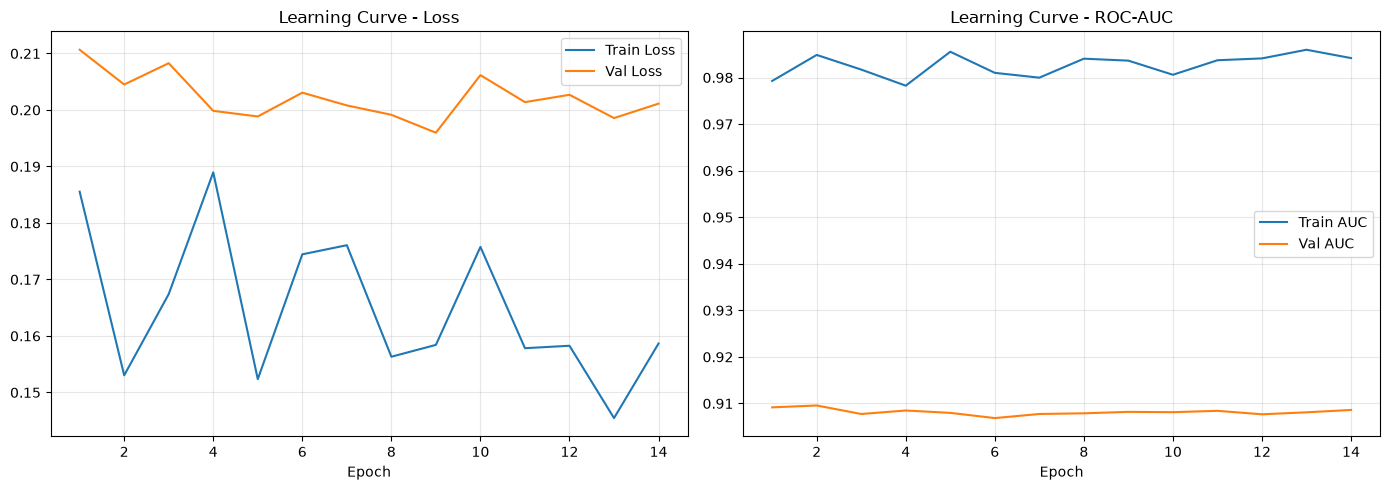


ĐÁNH GIÁ TRÊN TẬP TEST HOLD-OUT (15% ĐỘC LẬP)
🎯 Test ROC-AUC Score: 0.9348
🎯 Test PR-AUC Score:  0.3647

Confusion Matrix (Rows: True, Cols: Pred):
[[1113   60]
 [  11   21]]

Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

    Khỏe (0)     0.9902    0.9488    0.9691      1173
    Bệnh (1)     0.2593    0.6562    0.3717        32

    accuracy                         0.9411      1205
   macro avg     0.6247    0.8025    0.6704      1205
weighted avg     0.9708    0.9411    0.9532      1205



In [13]:
# === 7) Huấn Luyện với Callbacks & Đánh Giá Đa Ngưỡng (Threshold Sweep) ===

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_fscore_support

# --- Callbacks chống Overfitting ---
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

# --- 1) Training ---
history = model.fit(
    x=[X_train_job, X_train_seq, X_train_num],
    y=y_train,
    validation_data=([X_val_job, X_val_seq, X_val_num], y_val),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1,
)

h = history.history
epochs_range = range(1, len(h["loss"]) + 1)

# --- 2) Biểu đồ Learning Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, h["loss"], label="Train Loss")
axes[0].plot(epochs_range, h["val_loss"], label="Val Loss")
axes[0].set_title("Learning Curve - Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, h["auc"], label="Train AUC")
axes[1].plot(epochs_range, h["val_auc"], label="Val AUC")
axes[1].set_title("Learning Curve - ROC-AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("output", exist_ok=True)
plt.savefig("output/learning_curves.png", dpi=150)
plt.show()

# --- 3) Đánh giá Độc lập trên tập TEST (Hold-out Set) ---
print("\n" + "=" * 60)
print("ĐÁNH GIÁ TRÊN TẬP TEST HOLD-OUT (15% ĐỘC LẬP)")
print("=" * 60)

y_test_prob = model.predict([X_test_job, X_test_seq, X_test_num], batch_size=64, verbose=0).ravel()
test_auc = roc_auc_score(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)

print(f"🎯 Test ROC-AUC Score: {test_auc:.4f}")
print(f"🎯 Test PR-AUC Score:  {test_pr_auc:.4f}\n")

# --- 4) Quét các Ngưỡng Quyết Định (Threshold Sweep) ---
thresholds = [0.50, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
sweep_rows = []
for thresh in thresholds:
    y_pred_t = (y_test_prob >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_t, average="binary", pos_label=1, zero_division=0)
    sweep_rows.append({
        "Threshold": thresh,
        "Precision (Bệnh)": f"{prec:.4f}",
        "Recall (Bệnh)": f"{rec:.4f}",
        "F1-Score": f"{f1:.4f}",
        "Đoán Đúng Bệnh (TP)": f"{tp}/{tp+fn}",
        "Báo Nhầm (FP)": fp,
    })

df_sweep = pd.DataFrame(sweep_rows)
print("📊 BẢNG SO SÁNH HIỆU NĂNG THEO TỪNG NGƯỠNG PHÂN LOẠI (THRESHOLD):")
print(df_sweep.to_string(index=False))

# --- 5) Báo cáo Chi tiết tại Ngưỡng Thresh = 0.70 ---
CHOSEN_THRESH = 0.70
y_test_pred_70 = (y_test_prob >= CHOSEN_THRESH).astype(int)
print(f"\n" + "-" * 60)
print(f"CHI TIẾT ĐÁNH GIÁ TẠI NGƯỠNG THRESHOLD = {CHOSEN_THRESH}:")
print("-" * 60)
print("Confusion Matrix (Rows: True, Cols: Pred):")
print(confusion_matrix(y_test, y_test_pred_70))
print(f"\nClassification Report (Threshold {CHOSEN_THRESH}):")
print(classification_report(y_test, y_test_pred_70, target_names=["Khỏe (0)", "Bệnh (1)"], digits=4))


In [11]:
# === 8) Trích Xuất Vector Đặc Trưng Lâm Sàng (32-dim) Phục Vụ Fusion (GNN) ===

import os
import numpy as np
import pandas as pd

print("🔄 Đang xây dựng Feature Extractor từ lớp 'fusion_dense'...")
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.get_layer("fusion_dense").output,
    name="timeseries_feature_extractor"
)

# Trích xuất vector 32 chiều cho TOÀN BỘ 8030 bệnh nhân
ts_vectors = feature_extractor.predict(
    [X_job_all, X_seq_all, X_num_all],
    batch_size=64,
    verbose=1
)

print(f"✅ Trích xuất thành công: shape = {ts_vectors.shape}")

# Tạo DataFrame lưu thông tin vector cùng file_name để match với nhánh Ảnh X-quang
df_vectors = pd.DataFrame(ts_vectors, columns=[f"ts_feat_{i}" for i in range(ts_vectors.shape[1])])
if file_names is not None and len(file_names) == len(df_vectors):
    df_vectors.insert(0, "file_name", file_names)

# Lưu kết quả ra file chuẩn trong thư mục output/
os.makedirs("output", exist_ok=True)
parquet_path = "output/timeseries_features.parquet"
npy_path = "output/timeseries_features.npy"

df_vectors.to_parquet(parquet_path, index=False)
np.save(npy_path, ts_vectors)

print(f"\n🎉 ĐÃ XUẤT THÀNH CÔNG VECTOR CHO NHÁNH FUSION:")
print(f"- File Parquet (kèm file_name): {parquet_path}")
print(f"- File Npy (chỉ matrix float32):  {npy_path}")

🔄 Đang xây dựng Feature Extractor từ lớp 'fusion_dense'...


NameError: name 'X_num_all' is not defined